Imports and Environment Setup

In [ ]:
%pip install openai-whisper whisperx demucs jiwer webvtt-py matplotlib seaborn pandas

In [2]:
import os
import re
import time
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import webvtt
import jiwer
import whisper
import whisperx
import torch
from tqdm.notebook import tqdm

# Set device to GPU if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

# Paths relative to the pilot_testing folder
# Adjust 'raw_dataset/subset/' if you named the subset folder differently
AUDIO_FILES = [
    "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 04. Architectures Grids.mp4",
    "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 11. Representation Learning Reconstruction-Based.mp4",
    "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 21. Language Models.mp4"
]
GROUND_TRUTH_VTTS = [
    "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 04. Architectures Grids.en-j3PyPqV-e1s.vtt",
    "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 11. Representation Learning Reconstruction-Based.en-j3PyPqV-e1s.vtt",
    "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 21. Language Models.en-j3PyPqV-e1s.vtt"
]

results_data = []

🚀 Using device: cuda


Text Normalization & VTT Parsing Functions

In [3]:
def normalize_text(text):
    """
    Advanced text normalization for ASR vs. Human CC evaluation.
    Strips metadata, punctuation, fillers, and corrects stuttering disfluencies.
    """
    # 1. Remove Acoustic Annotations (e.g., [SQUEAKING], [RUSTLING], (laughs))
    text = re.sub(r'\[.*?\]|\(.*?\)', '', text)
    
    # 2. Remove Speaker Diarization Labels (e.g., "PHILLIP ISOLA: " or "SPEAKER 1:")
    text = re.sub(r'\b[A-Z\s]+:', '', text)
    
    # 3. Lowercase the entire text for case-insensitive processing
    text = text.lower()
    
    # 4. Remove standard punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # 5. Remove common conversational fillers
    fillers = [r'\bum\b', r'\buh\b', r'\bah\b', r'\bso\b', r'\blike\b', r'\byou know\b']
    for filler in fillers:
        text = re.sub(filler, '', text)
        
    # 6. Resolve the Double-Word/Stutter Problem
    text = re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', text)
    
    # 7. Clean up any extra/multiple whitespaces left behind
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def parse_vtt_to_text(vtt_path):
    """Extracts raw text from a VTT file."""
    if not os.path.exists(vtt_path):
        print(f"⚠️ Warning: Could not find {vtt_path}")
        return ""
    vtt = webvtt.read(vtt_path)
    raw_text = " ".join([caption.text for caption in vtt])
    return normalize_text(raw_text)

def calculate_wer(ground_truth_path, hypothesis_text):
    """Calculates the Word Error Rate using jiwer."""
    gt_text = parse_vtt_to_text(ground_truth_path)
    hyp_text = normalize_text(hypothesis_text)
    if not gt_text:
        return 1.0 # 100% error if ground truth is missing
    return jiwer.wer(gt_text, hyp_text)

Method 1 - Standard Whisper

In [6]:
print("🧠 Loading Standard Whisper (Small)...")
whisper_model = whisper.load_model("small", device=DEVICE)

# Added tqdm wrapper here
for i, audio_path in enumerate(tqdm(AUDIO_FILES, desc="Standard Whisper Progress")):
    start_time = time.time()
    
    result = whisper_model.transcribe(audio_path, language="en", verbose=True)
    
    process_time = time.time() - start_time
    wer_score = calculate_wer(GROUND_TRUTH_VTTS[i], result["text"])
    
    results_data.append({
        "Method": "Standard Whisper",
        "Video": f"Clip {i+1}",
        "Time (s)": process_time,
        "WER": wer_score * 100 
    })
    # Changed print to tqdm.write to prevent the progress bar from glitching
    tqdm.write(f"✅ Finished Clip {i+1} in {process_time:.2f}s | WER: {wer_score*100:.2f}%")

🧠 Loading Standard Whisper (Small)...


100%|███████████████████████████████████████| 461M/461M [00:07<00:00, 61.1MiB/s]


Standard Whisper Progress:   0%|          | 0/3 [00:00<?, ?it/s]

[00:00.000 --> 00:19.520]  So today we're going to start off the first of a series of lectures on machine learning
[00:19.520 --> 00:21.680]  architectures.
[00:21.680 --> 00:29.280]  And so moving beyond kind of the very vanilla architecture we've been talking about so far,
[00:29.280 --> 00:34.560]  which is the multilayer perceptron, and starting to discuss different ways that we can encode
[00:34.560 --> 00:39.680]  structure or essentially build hypotheses about the space of models that we want to
[00:39.680 --> 00:46.480]  optimize over directly into the architecture of the model that we're going to optimize.
[00:46.480 --> 00:50.120]  So what that's going to look like today, first we're going to sort of have a broader discussion
[00:50.120 --> 00:56.640]  about why we want to build better architectures and kind of what makes an architecture better.
[00:56.640 --> 01:02.080]  And then we're going to do a bit of a deep dive on convolutional layers as like one specific
[01:02.080 -

Method 2 - Demucs + Whisper

In [7]:
# Added tqdm wrapper here
for i, audio_path in enumerate(tqdm(AUDIO_FILES, desc="Demucs + Whisper Progress")):
    start_time = time.time()
    
    # Run Demucs to separate vocals
    demucs_cmd = ["python", "-m", "demucs", "-n", "htdemucs", "--two-stems=vocals", audio_path]
    subprocess.run(demucs_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    # Re-construct the path to the extracted vocal track
    base_name = os.path.splitext(os.path.basename(audio_path))[0]
    vocal_path = f"separated/htdemucs/{base_name}/vocals.wav"
    
    # Pass the clean audio to standard Whisper
    result = whisper_model.transcribe(vocal_path, language="en", verbose=True)
    
    process_time = time.time() - start_time
    wer_score = calculate_wer(GROUND_TRUTH_VTTS[i], result["text"])
    
    results_data.append({
        "Method": "Demucs + Whisper",
        "Video": f"Clip {i+1}",
        "Time (s)": process_time,
        "WER": wer_score * 100
    })
    tqdm.write(f"✅ Finished Clip {i+1} in {process_time:.2f}s | WER: {wer_score*100:.2f}%")

Demucs + Whisper Progress:   0%|          | 0/3 [00:00<?, ?it/s]

[00:00.000 --> 00:19.520]  So today we're going to start off the first of a series of lectures on machine learning
[00:19.520 --> 00:21.680]  architectures.
[00:21.680 --> 00:29.280]  And so moving beyond kind of the very vanilla architecture we've been talking about so far,
[00:29.280 --> 00:34.560]  which is the multilayer perceptron, and starting to discuss different ways that we can encode
[00:34.560 --> 00:39.680]  structure or essentially build hypotheses about the space of models that we want to
[00:39.680 --> 00:46.480]  optimize over directly into the architecture of the model that we're going to optimize.
[00:46.480 --> 00:50.120]  So what that's going to look like today, first we're going to sort of have a broader discussion
[00:50.120 --> 00:56.640]  about why we want to build better architectures and kind of what makes an architecture better.
[00:56.640 --> 01:02.080]  And then we're going to do a bit of a deep dive on convolutional layers as like one specific
[01:02.080 -

Method 3 - WhisperX (Forced Alignment)

In [5]:
print("🧠 Loading WhisperX (Small)...")
whisperx_model = whisperx.load_model("small", DEVICE, compute_type="float16" if DEVICE=="cuda" else "int8")

# Added tqdm wrapper here
for i, audio_path in enumerate(tqdm(AUDIO_FILES, desc="WhisperX Progress")):
    start_time = time.time()
    
    # 1. Transcribe (Removed print_progress=True to prevent crashes)
    audio = whisperx.load_audio(audio_path)
    result = whisperx_model.transcribe(audio, batch_size=16)
    
    # 2. Align timestamps using wav2vec2.0
    model_a, metadata = whisperx.load_align_model(language_code="en", device=DEVICE)
    aligned_result = whisperx.align(result["segments"], model_a, metadata, audio, DEVICE, return_char_alignments=False)
    
    # Combine text for WER calculation
    full_text = " ".join([seg["text"] for seg in aligned_result["segments"]])
    
    process_time = time.time() - start_time
    wer_score = calculate_wer(GROUND_TRUTH_VTTS[i], full_text)
    
    # Appending results without the Drift metric
    results_data.append({
        "Method": "WhisperX",
        "Video": f"Clip {i+1}",
        "Time (s)": process_time,
        "WER": wer_score * 100
    })
    
    # Backup to disk immediately so you never lose data to a Kaggle crash!
    pd.DataFrame(results_data).to_csv("backup_results.csv", index=False)
    
    # Cleaned up print statement
    tqdm.write(f"✅ Finished Clip {i+1} in {process_time:.2f}s | WER: {wer_score*100:.2f}%")

🧠 Loading WhisperX (Small)...
2026-06-02 15:28:26 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-06-02 15:28:26 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.5. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../usr/local/lib/python3.12/dist-packages/whisperx/assets/pytorch_model.bin`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.5. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../usr/local/lib/python3.12/dist-packages/whisperx/assets/pytorch_model.bin`


WhisperX Progress:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(


2026-06-02 15:28:48 - whisperx.asr - INFO - Detected language: en (0.99) in first 30s of audio
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960_asr_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960_asr_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 346MB/s]


✅ Finished Clip 1 in 139.00s | WER: 7.32%
2026-06-02 15:31:07 - whisperx.asr - INFO - Detected language: en (1.00) in first 30s of audio
✅ Finished Clip 2 in 145.97s | WER: 7.26%
2026-06-02 15:33:32 - whisperx.asr - INFO - Detected language: en (0.98) in first 30s of audio
✅ Finished Clip 3 in 138.02s | WER: 5.68%


Evaluation

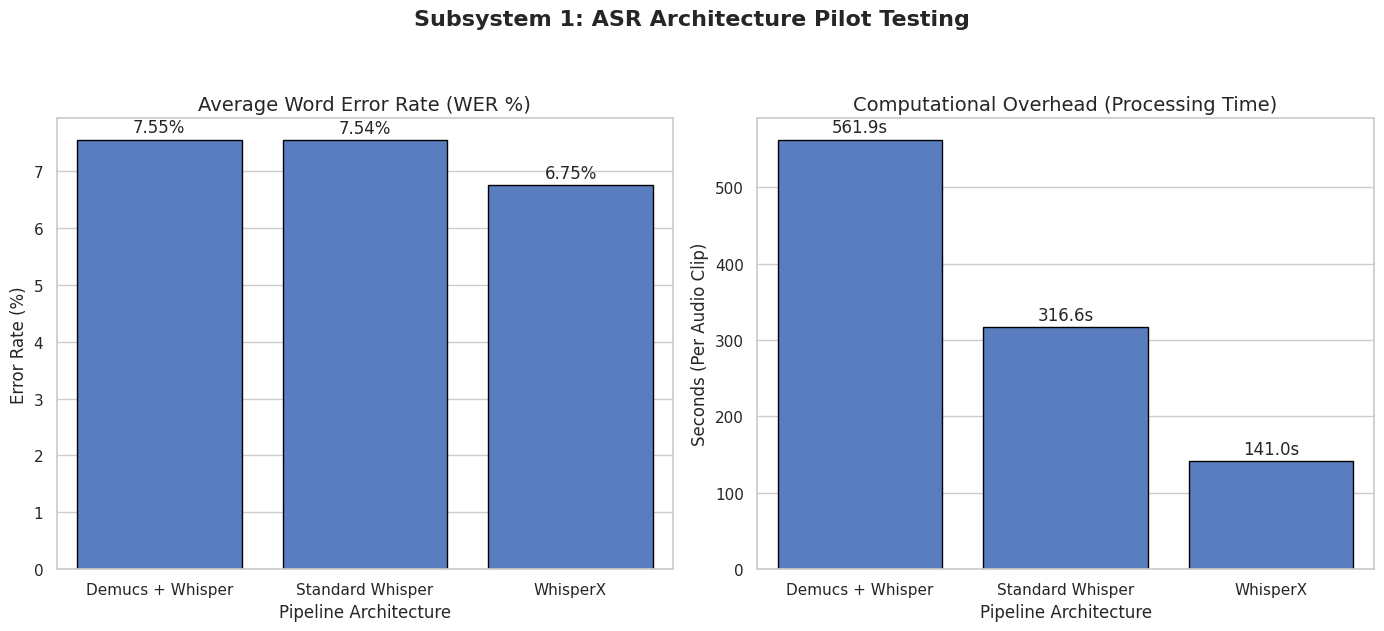


📊 Raw Performance Table:


WER                                    Time (s)  \
Method Demucs + Whisper Standard Whisper  WhisperX Demucs + Whisper   
Video                                                                 
Clip 1         7.837233         7.829511  7.319898       576.563522   
Clip 2         8.245496         8.297825  7.258728       576.932979   
Clip 3         6.560983         6.485133  5.681129       532.287544   

                                     
Method Standard Whisper    WhisperX  
Video                                
Clip 1       327.402595  138.997042  
Clip 2       334.145601  145.969756  
Clip 3       288.225412  138.016929

In [8]:
from IPython.display import display

# Create a DataFrame
df = pd.DataFrame(results_data)

# Calculate averages across the 3 video clips
avg_df = df.groupby("Method").mean(numeric_only=True).reset_index()

# Setup seaborn styles for academic plotting
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Subsystem 1: ASR Architecture Pilot Testing", fontsize=16, fontweight='bold', y=1.05)

# --- Graph 1: Word Error Rate (Lower is Better) ---
sns.barplot(ax=axes[0], x="Method", y="WER", data=avg_df, edgecolor="black")
axes[0].set_title("Average Word Error Rate (WER %)", fontsize=14)
axes[0].set_ylabel("Error Rate (%)")
axes[0].set_xlabel("Pipeline Architecture")

# Add data labels
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), textcoords = 'offset points')

# --- Graph 2: Processing Time / Speed (Lower is Better) ---
sns.barplot(ax=axes[1], x="Method", y="Time (s)", data=avg_df, edgecolor="black")
axes[1].set_title("Computational Overhead (Processing Time)", fontsize=14)
axes[1].set_ylabel("Seconds (Per Audio Clip)")
axes[1].set_xlabel("Pipeline Architecture")

# Add data labels
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}s', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# Print the Raw Data Table
print("\n📊 Raw Performance Table:")
display(df.pivot(index="Video", columns="Method", values=["WER", "Time (s)"]))

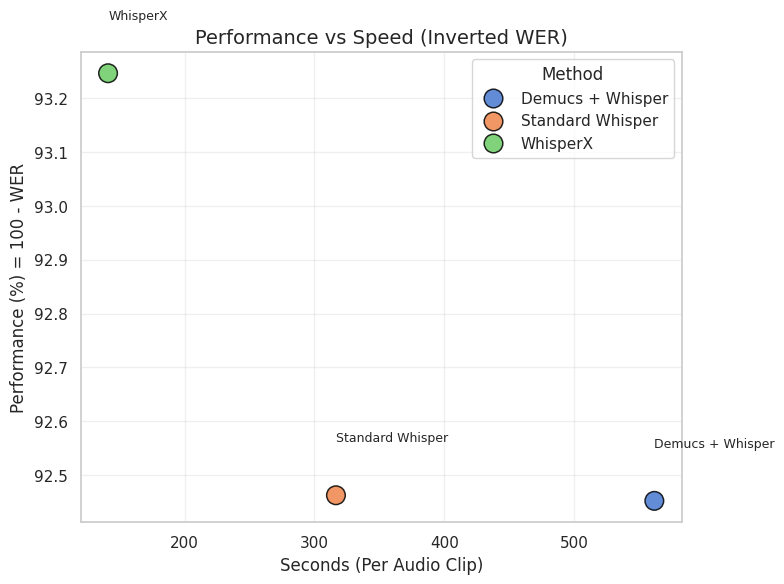

In [9]:
# Performance (inverted error rate) vs speed comparison
perf_df = avg_df.copy()
perf_df["Performance (%)"] = 100.0 - perf_df["WER"]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=perf_df,
    x="Time (s)",
    y="Performance (%)",
    hue="Method",
    s=180,
    edgecolor="black",
    alpha=0.85
 )

# Label points with method names
for _, row in perf_df.iterrows():
    plt.text(
        row["Time (s)"] + 0.02,
        row["Performance (%)"] + 0.1,
        row["Method"],
        fontsize=9
    )

plt.title("Performance vs Speed (Inverted WER)", fontsize=14)
plt.xlabel("Seconds (Per Audio Clip)")
plt.ylabel("Performance (%) = 100 - WER")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Save results to CSV
df.to_csv("transcription_results_raw.csv", index=False)
avg_df.to_csv("transcription_results_avg.csv", index=False)
perf_df.to_csv("transcription_results_perf_vs_speed.csv", index=False)

print("Saved:")
print("- transcription_results_raw.csv")
print("- transcription_results_avg.csv")
print("- transcription_results_perf_vs_speed.csv")

Saved:
- transcription_results_raw.csv
- transcription_results_avg.csv
- transcription_results_perf_vs_speed.csv
